In [1]:
# =============================================================
# 🔥 NAQAN: Final Corrected Version (OCTMNIST / BraTS)
# =============================================================
! pip install pennylane medmnist torch torchvision


import os, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
import medmnist
from medmnist import OCTMNIST
from torch import optim
from torchvision import transforms
from sklearn.metrics import normalized_mutual_info_score, adjusted_mutual_info_score
from torch.utils.data import DataLoader
from torchvision.models import vgg16, VGG16_Weights
from skimage.metrics import structural_similarity as sk_ssim
from tqdm import tqdm

# =============================
# Reproducibility & Device
# =============================
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================
# Quantum Setup
# =============================
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def q_circuit(inputs, weights):
    # Encoding
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)
        qml.RZ(inputs[i], wires=i)

    # Mixing
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # Trainable rotations
    for i in range(n_qubits):
        qml.RY(weights[i], wires=i)
        qml.RZ(weights[i + n_qubits], wires=i)

    # Entanglement
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i+1])
    qml.CNOT(wires=[n_qubits-1, 0])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# =============================
# Noise Embedding (FiLM)
# =============================
class NoiseEmbedding(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, 128),
            nn.GELU(),
            nn.Linear(128, channels * 2)
        )

    def forward(self, noise_level):
        emb = self.net(noise_level)
        gamma, beta = torch.chunk(emb, 2, dim=1)
        return gamma.unsqueeze(-1).unsqueeze(-1), beta.unsqueeze(-1).unsqueeze(-1)

# =============================
# QAN: Quantum Attention Network
# =============================
class QAN(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc_feat = nn.Sequential(
            nn.Linear(channels, 32),
            nn.GELU(),
            nn.Linear(32, n_qubits)
        )
        self.noise_to_quantum = nn.Linear(1, n_qubits * 2)
        self.fc_out = nn.Linear(n_qubits, channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, noise_level):
        b, c, _, _ = x.shape
        pooled = self.pool(x).view(b, c)
        q_inputs = self.fc_feat(pooled)
        q_weights = self.noise_to_quantum(noise_level)

        q_out = torch.stack([
            torch.stack(q_circuit(q_inputs[i], q_weights[i]))
            for i in range(b)
        ]).float()

        attn = self.sigmoid(self.fc_out(q_out)).view(b, c, 1, 1)
        return x * attn

# =============================
# NAQAN Block & Full Model
# =============================
class NAQANBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.relu = nn.ReLU()
        self.qan = QAN(channels)
        self.noise_emb = NoiseEmbedding(channels)

    def forward(self, x, noise_level):
        res = x
        out = self.relu(self.conv1(x))
        out = self.conv2(out)
        out = self.qan(out, noise_level)
        gamma, beta = self.noise_emb(noise_level)
        out = gamma * out + beta
        return res + out

class NAQAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Conv2d(1, 32, 3, padding=1)
        self.enc2 = nn.Conv2d(32, 64, 3, padding=1)
        self.block = NAQANBlock(64)
        self.dec1 = nn.Conv2d(64, 32, 3, padding=1)
        self.dec2 = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x, noise_level):
        e1 = torch.relu(self.enc1(x))
        e2 = torch.relu(self.enc2(e1))
        b = self.block(e2, noise_level)
        d1 = torch.relu(self.dec1(b))
        noise_pred = self.dec2(d1)
        return x - noise_pred

model = NAQAN().to(device)

# =============================
# Perceptual Loss (Normalized for VGG)
# =============================
vgg = vgg16(weights=VGG16_Weights.DEFAULT).features[:16].to(device).eval()
for p in vgg.parameters():
    p.requires_grad = False

# ImageNet normalization required by VGG
vgg_normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def perceptual_loss(x, y):
    # Scale from [-1, 1] to [0, 1]
    x_norm = (x + 1) / 2
    y_norm = (y + 1) / 2

    # Repeat to 3 channels and normalize
    x3 = vgg_normalize(x_norm.repeat(1, 3, 1, 1))
    y3 = vgg_normalize(y_norm.repeat(1, 3, 1, 1))

    return F.mse_loss(vgg(x3), vgg(y3))

# =============================
# Noise Injection
# =============================
def add_noise(x):
    noise_type = random.choice(["gaussian","speckle","poisson"])
    level = random.choice([0.05, 0.1, 0.2])

    if noise_type == "gaussian":
        noisy = x + torch.randn_like(x) * level
    elif noise_type == "speckle":
        noisy = x + x * torch.randn_like(x) * level
    else:
        x_denorm = (x * 0.5) + 0.5
        noisy = torch.poisson(x_denorm * 255.0) / 255.0
        noisy = noisy * 2 - 1

    return noisy.clamp(-1, 1), level

def get_noise_tensor(lvl, batch_size):
    return (torch.tensor([[lvl]], device=device) * 10).repeat(batch_size, 1).float()

# =============================
# Metrics (Fixed to loop over batch & use CPU numpy)
# =============================
def compute_psnr(x, y):
    x = (x + 1) / 2
    y = (y + 1) / 2
    mse = F.mse_loss(x, y)
    return 20 * torch.log10(1.0 / torch.sqrt(mse + 1e-8))

def compute_ssim(x, y):
    x_np = ((x + 1) / 2).clamp(0, 1).cpu().detach().numpy()
    y_np = ((y + 1) / 2).clamp(0, 1).cpu().detach().numpy()

    # Compute SSIM per image in the batch and average
    batch_ssim = [sk_ssim(x_np[i, 0], y_np[i, 0], data_range=1.0) for i in range(x_np.shape[0])]
    return np.mean(batch_ssim)

def _bin(img):
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return np.digitize(img.flatten(), np.linspace(0, 1, 64))

def compute_nmi(x, y):
    x_np = x.cpu().detach().numpy()
    y_np = y.cpu().detach().numpy()
    batch_nmi = [normalized_mutual_info_score(_bin(x_np[i]), _bin(y_np[i])) for i in range(x_np.shape[0])]
    return np.mean(batch_nmi)

def compute_ami(x, y):
    x_np = x.cpu().detach().numpy()
    y_np = y.cpu().detach().numpy()
    batch_ami = [adjusted_mutual_info_score(_bin(x_np[i]), _bin(y_np[i])) for i in range(x_np.shape[0])]
    return np.mean(batch_ami)

# =============================
# Data (Added Dataloaders)
# =============================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Initialize the datasets!
train_data = OCTMNIST(split='train', transform=transform, download=True)
test_data = OCTMNIST(split='test', transform=transform, download=True)

# Using batch size of 16 to prevent OOM with quantum simulations
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# =============================
# Training
# =============================
optimizer = optim.Adam(model.parameters(), lr=2e-4)
l1_loss = nn.L1Loss()

print("Starting Noise-Adaptive Quantum Training...")
for epoch in range(5):
    model.train()
    t_loss, t_psnr, t_ssim, t_nmi, t_ami = [], [], [], [], []
    pbar = tqdm(train_loader)

    for images, _ in pbar:
        images = images.to(device)

        noisy, lvl = add_noise(images)
        lvl_tensor = get_noise_tensor(lvl, images.size(0))

        optimizer.zero_grad()
        denoised = model(noisy, lvl_tensor)

        loss = l1_loss(denoised, images) + 0.1 * perceptual_loss(denoised, images)
        loss.backward()
        optimizer.step()

        psnr_val = compute_psnr(denoised, images).item()
        ssim_val = compute_ssim(denoised, images)
        nmi = compute_nmi(denoised, images)
        ami = compute_ami(denoised, images)

        t_loss.append(loss.item())
        t_psnr.append(psnr_val)
        t_ssim.append(ssim_val)
        t_nmi.append(nmi)
        t_ami.append(ami)

        pbar.set_description(f"Epoch {epoch+1} | Loss {loss.item():.4f} | PSNR {psnr_val:.2f}dB | SSIM {ssim_val:.4f} | NMI {nmi:.4f} | AMI {ami:.4f}")

    # ===== Validation =====
    model.eval()
    loss_total, psnr_total, ssim_total, nmi_total, ami_total = 0, 0, 0, 0, 0

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)

            noisy, lvl = add_noise(images)
            lvl_tensor = get_noise_tensor(lvl, images.size(0))

            denoised = model(noisy, lvl_tensor)
            current_loss = l1_loss(denoised, images) + 0.1 * perceptual_loss(denoised, images)

            loss_total += current_loss.item()
            psnr_total += compute_psnr(denoised, images).item()
            ssim_total += compute_ssim(denoised, images)
            nmi_total  += compute_nmi(denoised, images)
            ami_total  += compute_ami(denoised, images)

    print(f"\nEpoch {epoch+1} Validation Results:")
    print(f"Loss: {loss_total/len(test_loader):.4f}")
    print(f"PSNR: {psnr_total/len(test_loader):.2f}")
    print(f"SSIM: {ssim_total/len(test_loader):.4f}")
    print(f"NMI : {nmi_total/len(test_loader):.4f}")
    print(f"AMI : {ami_total/len(test_loader):.4f}\n")

print("Training Complete. Model is now fully Noise-Adaptive in the Quantum domain.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 59.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 114.2 MB/s eta 0:00:0000:0100:01
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 167MB/s]  
100%|██████████| 54.9M/54.9M [00:41<00:00, 1.33MB/s]


Starting Noise-Adaptive Quantum Training...


Epoch 1 | Loss 0.1662 | PSNR 38.47dB | SSIM 0.9806 | NMI 0.6658 | AMI 0.5666: 100%|██████████| 3047/3047 [1:30:08<00:00,  1.77s/it]



Epoch 1 Validation Results:
Loss: 0.2520
PSNR: 34.62
SSIM: 0.9599
NMI : 0.5895
AMI : 0.4657



...


Epoch 3 Validation Results:
Loss: 0.2153
PSNR: 36.12
SSIM: 0.9674
NMI : 0.6074
AMI : 0.4891



Epoch 4 | Loss 0.2532 | PSNR 33.99dB | SSIM 0.9608 | NMI 0.5723 | AMI 0.4212: 100%|██████████| 3047/3047 [1:30:30<00:00,  1.78s/it]



Epoch 4 Validation Results:
Loss: 0.2120
PSNR: 36.05
SSIM: 0.9674
NMI : 0.6115
AMI : 0.4945



Epoch 5 | Loss 0.2367 | PSNR 34.20dB | SSIM 0.9629 | NMI 0.5847 | AMI 0.4466: 100%|██████████| 3047/3047 [1:30:07<00:00,  1.77s/it]



Epoch 5 Validation Results:
Loss: 0.2105
PSNR: 36.05
SSIM: 0.9692
NMI : 0.6183
AMI : 0.5042

Training Complete. Model is now fully Noise-Adaptive in the Quantum domain.


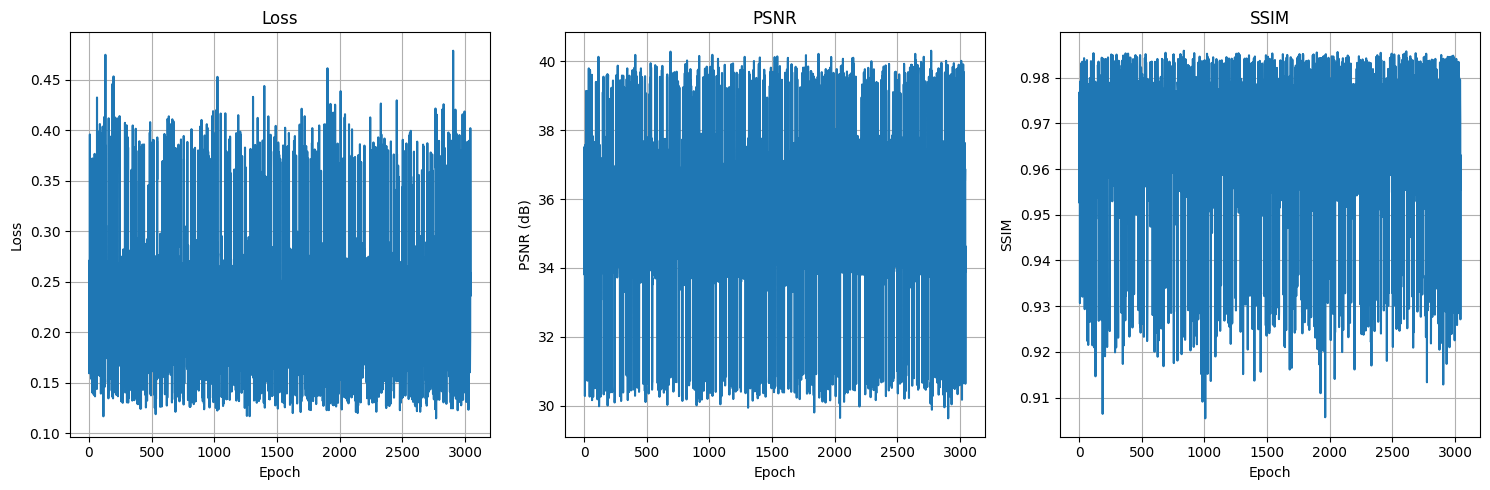

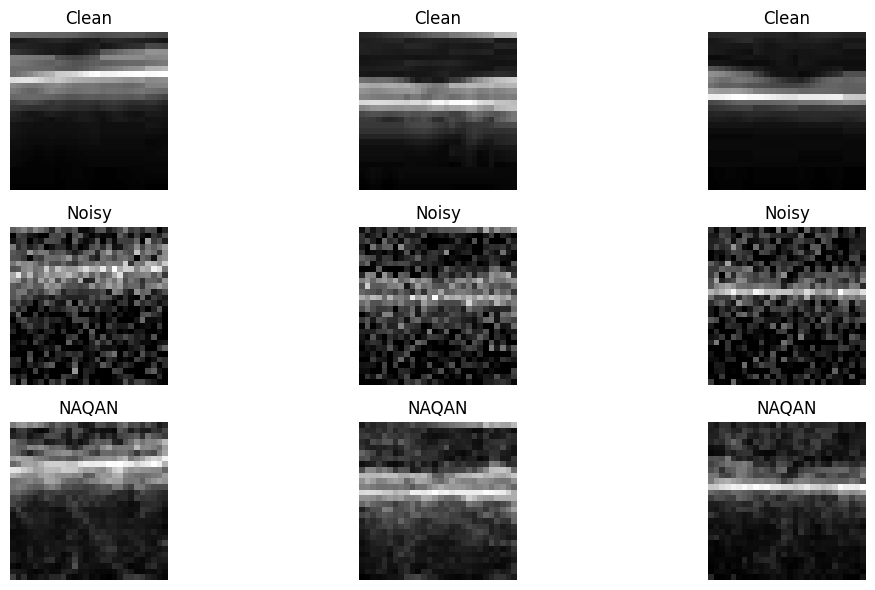

Ploting Curves Visualization 


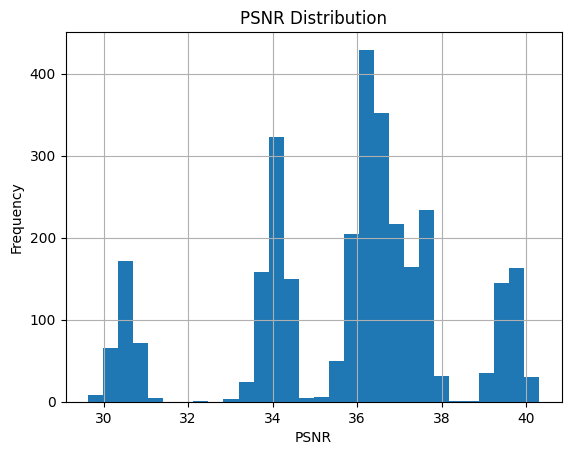

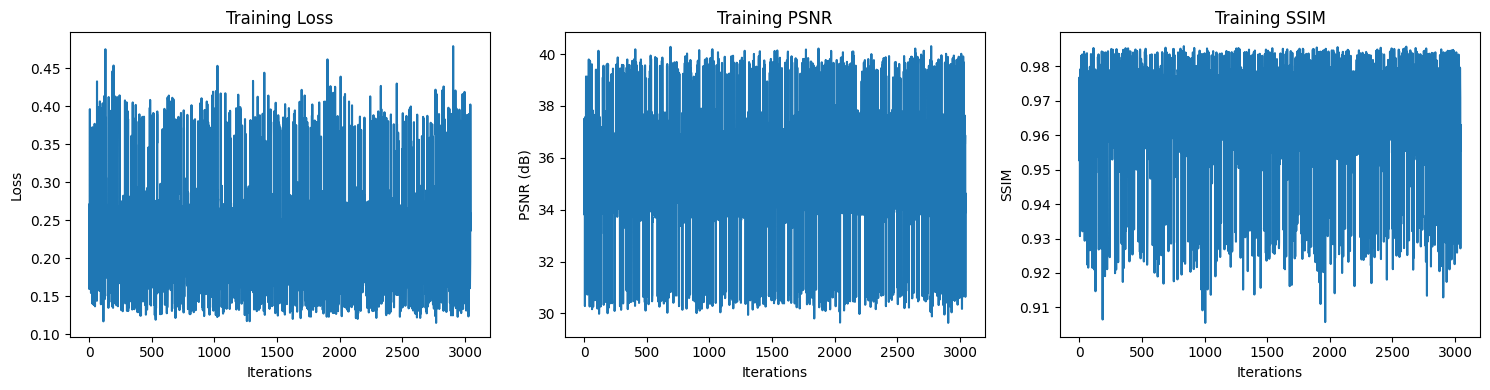


--- Qualitative Visualization ---


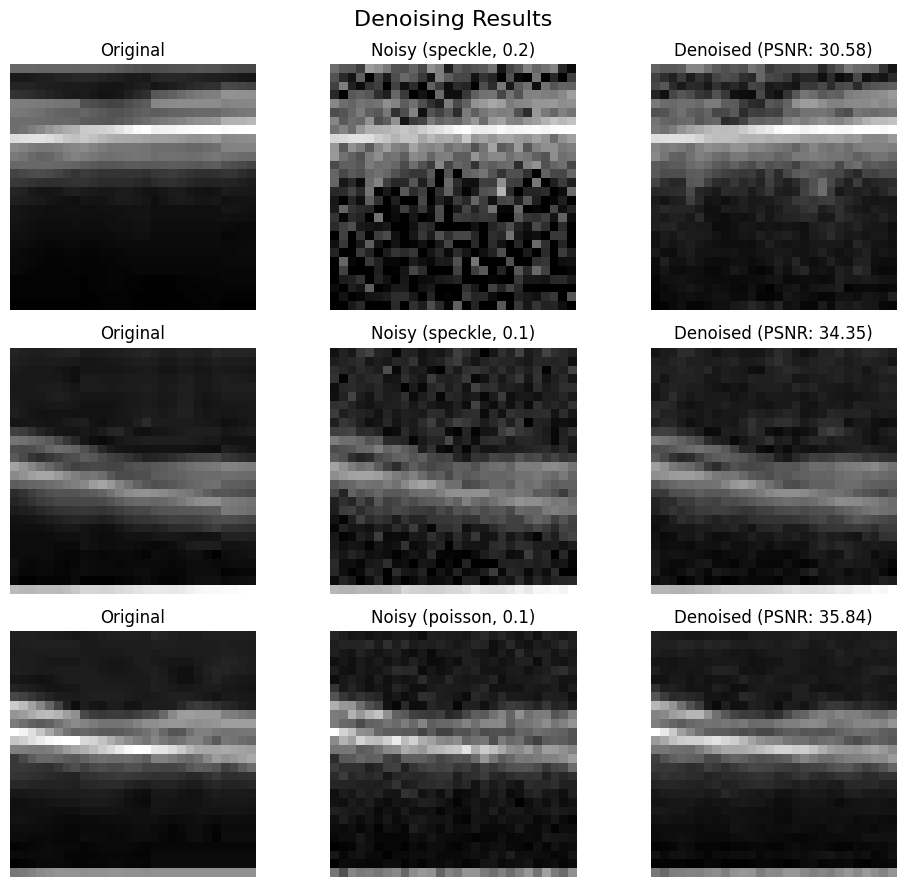


--- Visualizing Quantum Attention ---


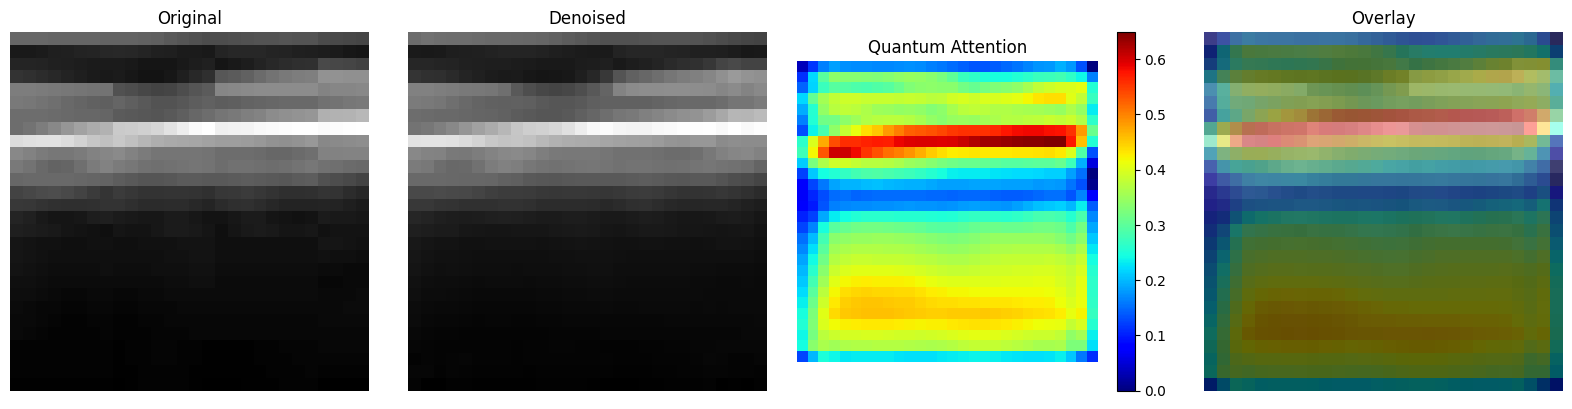


--- Starting Robustness Evaluation ---
GAUSSIAN (0.0) → PSNR: 43.46, SSIM: 0.9958
GAUSSIAN (0.05) → PSNR: 36.11, SSIM: 0.9618
GAUSSIAN (0.1) → PSNR: 31.47, SSIM: 0.9043
GAUSSIAN (0.2) → PSNR: 26.93, SSIM: 0.8028
SPECKLE (0.0) → PSNR: 43.46, SSIM: 0.9958
SPECKLE (0.05) → PSNR: 38.64, SSIM: 0.9740
SPECKLE (0.1) → PSNR: 34.54, SSIM: 0.9350
SPECKLE (0.2) → PSNR: 30.29, SSIM: 0.8667
POISSON (0.0) → PSNR: 35.11, SSIM: 0.9671
POISSON (0.05) → PSNR: 35.38, SSIM: 0.9697
POISSON (0.1) → PSNR: 35.62, SSIM: 0.9722
POISSON (0.2) → PSNR: 36.00, SSIM: 0.9754

--- Evaluating Clean Performance ---
Clean → PSNR: 43.383442759513855 SSIM: 0.9958496642813004

--- Visualizing Results ---


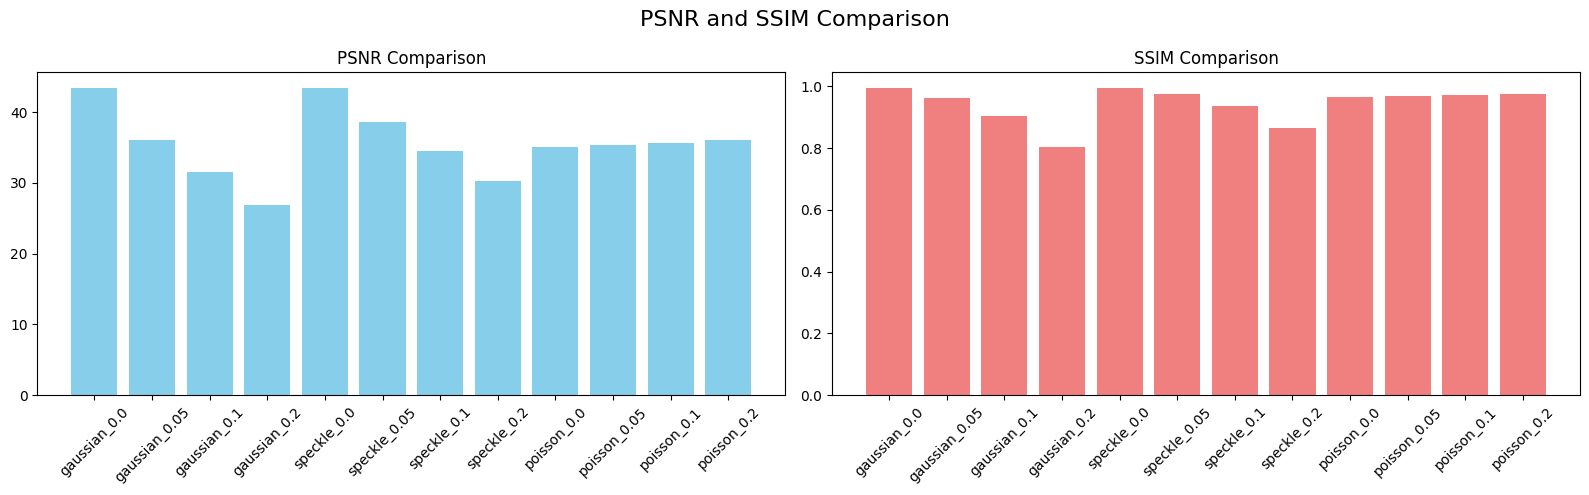

In [5]:
# NAQAN Evaluation & Visualization (Clean Version)

import matplotlib.pyplot as plt
import random 

# Qualitative comparison of denoising performance. From top to bottom: clean images, noisy inputs, and outputs from the proposed NAQAN model. The proposed method effectively removes noise while preserving fine anatomical structures.

def plot_training_curves(losses, psnrs, ssims):
    epochs = range(1, len(losses) + 1)

    # -----------------------------
    # Individual Plots
    # -----------------------------
    plt.figure()
    plt.plot(epochs, losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.grid()
    plt.savefig("loss_curve.png", dpi=300)
    plt.close()

    plt.figure()
    plt.plot(epochs, psnrs)
    plt.xlabel("Epoch")
    plt.ylabel("PSNR (dB)")
    plt.title("PSNR Improvement")
    plt.grid()
    plt.savefig("psnr_curve.png", dpi=300)
    plt.close()

    plt.figure()
    plt.plot(epochs, ssims)
    plt.xlabel("Epoch")
    plt.ylabel("SSIM")
    plt.title("SSIM Improvement")
    plt.grid()
    plt.savefig("ssim_curve.png", dpi=300)
    plt.close()

    # -----------------------------
    # Combined Figure (BEST for paper)
    # -----------------------------
    plt.figure(figsize=(15, 5))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.grid()

    # PSNR
    plt.subplot(1, 3, 2)
    plt.plot(epochs, psnrs)
    plt.xlabel("Epoch")
    plt.ylabel("PSNR (dB)")
    plt.title("PSNR")
    plt.grid()

    # SSIM
    plt.subplot(1, 3, 3)
    plt.plot(epochs, ssims)
    plt.xlabel("Epoch")
    plt.ylabel("SSIM")
    plt.title("SSIM")
    plt.grid()

    plt.tight_layout()
    plt.savefig("combined_curves.png", dpi=300)
    plt.show()

# Redefine add_noise locally for show_results to avoid conflicts
def add_noise_for_show_results(x):
    noise_type = random.choice(["gaussian","speckle","poisson"])
    level = random.choice([0.05, 0.1, 0.2])

    if noise_type == "gaussian":
        noisy = x + torch.randn_like(x) * level
    elif noise_type == "speckle":
        noisy = x + x * torch.randn_like(x) * level
    else:
        x_denorm = (x * 0.5) + 0.5
        noisy = torch.poisson(x_denorm * 255.0) / 255.0
        noisy = noisy * 2 - 1

    return noisy.clamp(-1, 1), level

def show_results(model, loader):

    model.eval()

    images, _ = next(iter(loader)) # Unpack the tuple to get only the images
    images = images.to(device)

    noisy, lvl = add_noise_for_show_results(images) # Use the locally defined add_noise
    lvl_tensor = torch.tensor([[lvl]], device=device).repeat(images.size(0), 1).float()

    with torch.no_grad():
        denoised = model(noisy, lvl_tensor)

    # num_images_to_show = images.shape[0] # Use the actual batch size
    num_images_to_show = 3 # Use the actual batch size
    fig, axs = plt.subplots(3, num_images_to_show, figsize=(12, 6))

    for i in range(num_images_to_show):
        axs[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
        axs[0, i].set_title("Clean")
        axs[0, i].axis('off')

        axs[1, i].imshow(noisy[i].cpu().squeeze(), cmap='gray')
        axs[1, i].set_title("Noisy")
        axs[1, i].axis('off')

        axs[2, i].imshow(denoised[i].cpu().squeeze(), cmap='gray')
        axs[2, i].set_title("NAQAN")
        axs[2, i].axis('off')

    plt.tight_layout()
    plt.savefig("qualitative_results.png", dpi=300)
    plt.show()

def plot_psnr_distribution(psnr_values):

    plt.figure()
    plt.hist(psnr_values, bins=30)
    plt.xlabel("PSNR")
    plt.ylabel("Frequency")
    plt.title("PSNR Distribution")
    plt.grid()
    plt.savefig("psnr_hist.png", dpi=300)




plot_training_curves(t_loss, t_psnr, t_ssim)
show_results(model, test_loader)
plot_psnr_distribution(t_psnr)


# 1. Training Curves Visualization
def plot_training_curves(t_loss, t_psnr, t_ssim):
    print("Ploting Curves Visualization ")
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.plot(t_loss)
    plt.title('Training Loss')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')

    plt.subplot(1, 3, 2)
    plt.plot(t_psnr)
    plt.title('Training PSNR')
    plt.xlabel('Iterations')
    plt.ylabel('PSNR (dB)')

    plt.subplot(1, 3, 3)
    plt.plot(t_ssim)
    plt.title('Training SSIM')
    plt.xlabel('Iterations')
    plt.ylabel('SSIM')

    plt.tight_layout()
    plt.show()
    
# 2. Noise Injection (Unified)
def add_noise(x, noise_type, level):
    if noise_type == "gaussian":
        noisy = x + torch.randn_like(x) * level

    elif noise_type == "speckle":
        noisy = x + x * torch.randn_like(x) * level

    else:  # poisson
        x_denorm = (x * 0.5) + 0.5
        noisy = torch.poisson(x_denorm * 255.0) / 255.0
        noisy = noisy * 2 - 1

    return noisy.clamp(-1, 1)


def get_noise_tensor(level, batch_size, device):
    return torch.tensor([[level]], device=device).repeat(batch_size, 1).float()

# 3. Qualitative Visualization (Clean vs Noisy vs Denoised)
def visualize_results(model, test_loader, device, num_images=3):
    print("\n--- Qualitative Visualization ---")

    model.eval()

    fig, axes = plt.subplots(num_images, 3, figsize=(10, 3 * num_images))
    fig.suptitle('Denoising Results', fontsize=16)

    with torch.no_grad():
        for i, (data, _) in enumerate(test_loader):
            if i >= num_images:
                break

            data = data.to(device)

            noise_type = random.choice(["gaussian", "speckle", "poisson"])
            level = random.choice([0.05, 0.1, 0.2])

            noisy = add_noise(data, noise_type, level)
            lvl_tensor = get_noise_tensor(level, data.size(0), device)

            out = model(noisy, lvl_tensor)

            original = (data[0] * 0.5 + 0.5).cpu().squeeze()
            noisy_img = (noisy[0] * 0.5 + 0.5).cpu().squeeze()
            denoised = (out[0] * 0.5 + 0.5).cpu().squeeze()

            axes[i, 0].imshow(original, cmap='gray')
            axes[i, 0].set_title("Original")

            axes[i, 1].imshow(noisy_img, cmap='gray')
            axes[i, 1].set_title(f"Noisy ({noise_type}, {level})")

            axes[i, 2].imshow(denoised, cmap='gray')
            axes[i, 2].set_title(f"Denoised (PSNR: {compute_psnr(out[0], data[0]):.2f})")

            for j in range(3):
                axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

# 4. Quantum Attention Visualization (Core Contribution)
def visualize_quantum_attention(model, image, noise_level, device):
    print("\n--- Visualizing Quantum Attention ---")
    model.eval()
    activations = {}

    def hook(module, input, output):
        activations['attn'] = output.detach()

    handle = model.block.qan.register_forward_hook(hook)

    with torch.no_grad():
        img = image.unsqueeze(0).to(device)
        lvl = torch.tensor([[noise_level]], device=device).float()
        out = model(img, lvl)

    handle.remove()

    feat = activations['attn'][0]
    attn_map = torch.mean(torch.abs(feat), dim=0).cpu().numpy()
    attn_map = (attn_map - attn_map.min()) / (attn_map.max() + 1e-8)

    fig, ax = plt.subplots(1, 4, figsize=(16, 4))

    ax[0].imshow(image.squeeze().cpu(), cmap='gray')
    ax[0].set_title("Original")

    ax[1].imshow(out.squeeze().cpu(), cmap='gray')
    ax[1].set_title("Denoised")

    im = ax[2].imshow(attn_map, cmap='jet')
    ax[2].set_title("Quantum Attention")
    plt.colorbar(im, ax=ax[2])

    ax[3].imshow(image.squeeze().cpu(), cmap='gray')
    ax[3].imshow(attn_map, cmap='jet', alpha=0.4)
    ax[3].set_title("Overlay")

    for a in ax:
        a.axis('off')

    plt.tight_layout()
    plt.show()

# 5. Robustness Evaluation (MAIN EXPERIMENT)
def evaluate_robustness(model, test_loader, device):
    print("\n--- Starting Robustness Evaluation ---")

    model.eval()

    noise_types = ["gaussian", "speckle", "poisson"]
    noise_levels = [0.0, 0.05, 0.1, 0.2]

    results = {}

    with torch.no_grad():
        for nt in noise_types:
            for nl in noise_levels:
                psnr_vals, ssim_vals = [], []

                for i, (images, _) in enumerate(test_loader):
                    if i > 20: break  # speed-up

                    images = images.to(device)
                    noisy = add_noise(images, nt, nl)
                    lvl = get_noise_tensor(nl, images.size(0), device)

                    out = model(noisy, lvl)

                    psnr_vals.append(compute_psnr(out, images).item())
                    ssim_vals.append(compute_ssim(out, images))

                results[f"{nt}_{nl}"] = {
                    "PSNR": np.mean(psnr_vals),
                    "SSIM": np.mean(ssim_vals)
                }

                print(f"{nt.upper()} ({nl}) → PSNR: {results[f'{nt}_{nl}']['PSNR']:.2f}, SSIM: {results[f'{nt}_{nl}']['SSIM']:.4f}")

    return results

# 6. Clean Image Evaluation
def evaluate_clean(model, test_loader, device):
    print("\n--- Evaluating Clean Performance ---")

    model.eval()
    psnr_vals, ssim_vals = [], []

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            lvl = get_noise_tensor(0.0, images.size(0), device)

            out = model(images, lvl)

            psnr_vals.append(compute_psnr(out, images).item())
            ssim_vals.append(compute_ssim(out, images))

    return np.mean(psnr_vals), np.mean(ssim_vals)

# 7. Result Visualization (Bar Charts)
def plot_results(results):
    print("\n--- Visualizing Results ---")

    labels = list(results.keys())
    psnr_vals = [results[k]["PSNR"] for k in labels] # skyblue
    ssim_vals = [results[k]["SSIM"] for k in labels] # lightcoral

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('PSNR and SSIM Comparison', fontsize=16)

    ax1.bar(labels, psnr_vals, color='skyblue')
    # ax1.bar(labels, psnr_vals)
    ax1.set_title("PSNR Comparison")
    ax1.tick_params(axis='x', rotation=45)

    ax2.bar(labels, ssim_vals, color='lightcoral')
    # ax2.bar(labels, ssim_vals)
    ax2.set_title("SSIM Comparison")
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


# Final Pipeline (How to Run Cleanly)
# 1. Plot training
plot_training_curves(t_loss, t_psnr, t_ssim)

# 2. Visual check
visualize_results(model, test_loader, device)

# 3. Quantum interpretability
sample, _ = next(iter(test_loader))
visualize_quantum_attention(model, sample[0], 0.2, device)

# 4. Robustness
results = evaluate_robustness(model, test_loader, device)

# 5. Clean performance
clean_psnr, clean_ssim = evaluate_clean(model, test_loader, device)
print("Clean → PSNR:", clean_psnr, "SSIM:", clean_ssim)

# 6. Plot results
plot_results(results)

